In [ ]:
import marimo as mo
mo.md("Hello!")

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">Hello!</span></span>

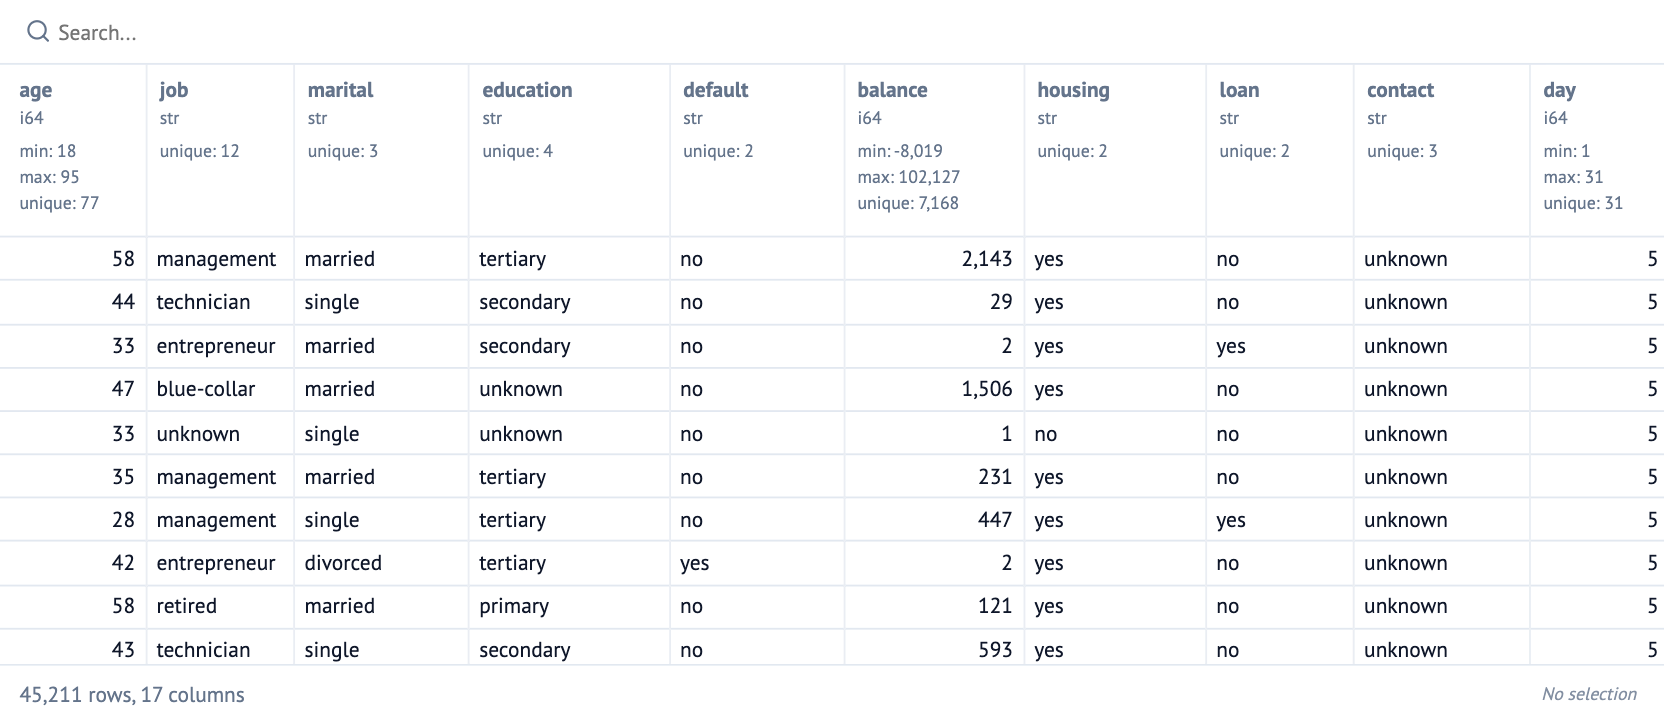

In [ ]:
import io
import zipfile
from urllib.request import urlopen

import polars as pl

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
with urlopen(url, timeout=120) as resp:
    outer_raw = resp.read()
outer = zipfile.ZipFile(io.BytesIO(outer_raw))
inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
with inner.open("bank-full.csv") as fp:
    df = pl.read_csv(fp, separator=";")
df = df.rename({"y": "subscribed"})
df

In [ ]:
total = df.height
n_yes = int((df["subscribed"] == "yes").sum())
pct = 100.0 * n_yes / total if total else 0.0

mo.md(
    f"""
## Subscription summary

- **Total rows:** {total:,}
- **Subscribed (yes):** {n_yes:,}
- **Conversion rate:** {pct:.2f}%
"""
)

<span class="markdown prose dark:prose-invert contents"><h2 id="subscription-summary">Subscription summary</h2>
<ul>
<li><strong>Total rows:</strong> 45,211</li>
<li><strong>Subscribed (yes):</strong> 5,289</li>
<li><strong>Conversion rate:</strong> 11.70%</li>
</ul></span>

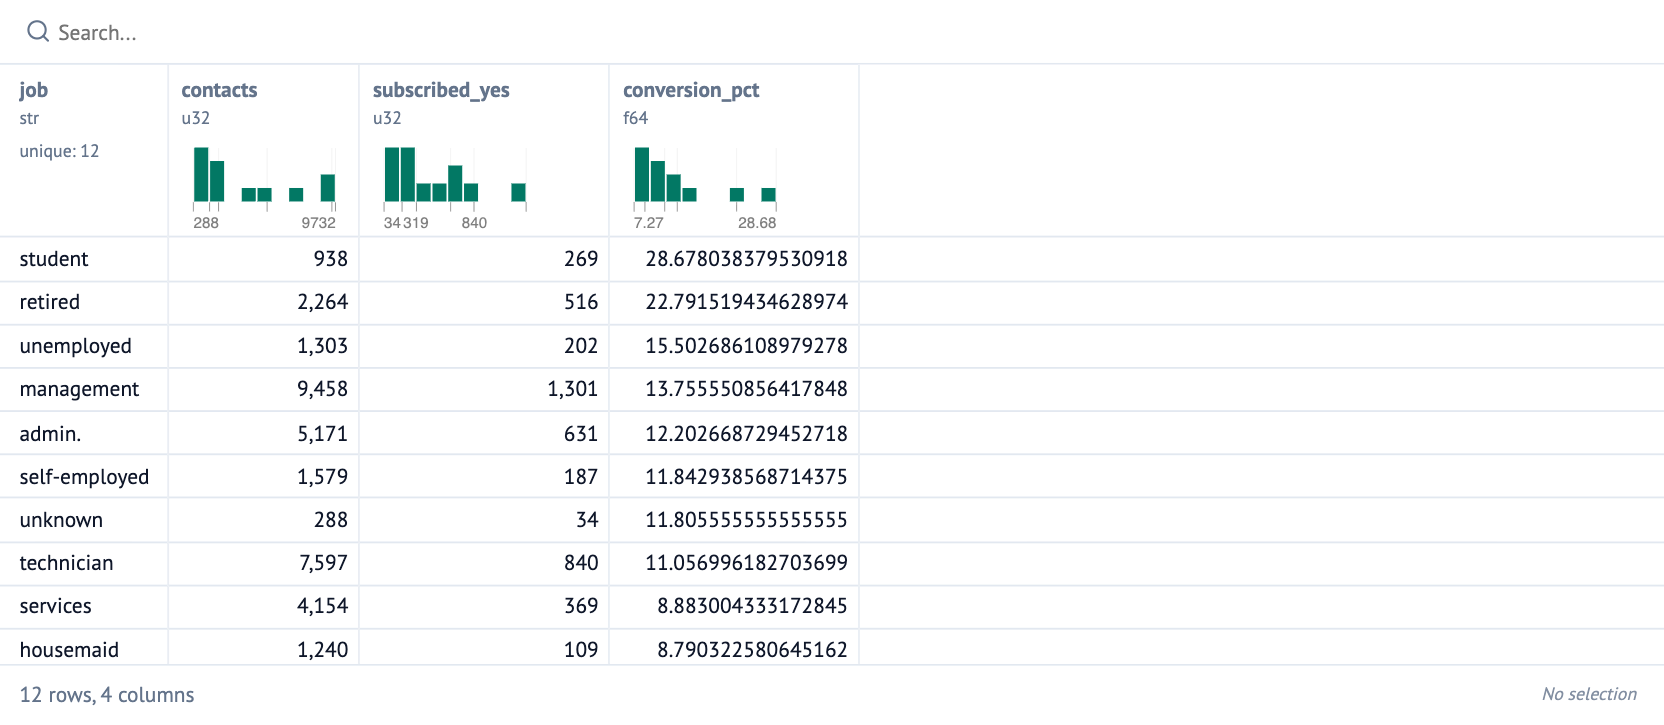

In [ ]:
by_job = (
    df.group_by("job")
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct")
    )
    .sort("conversion_pct", descending=True)
)
by_job

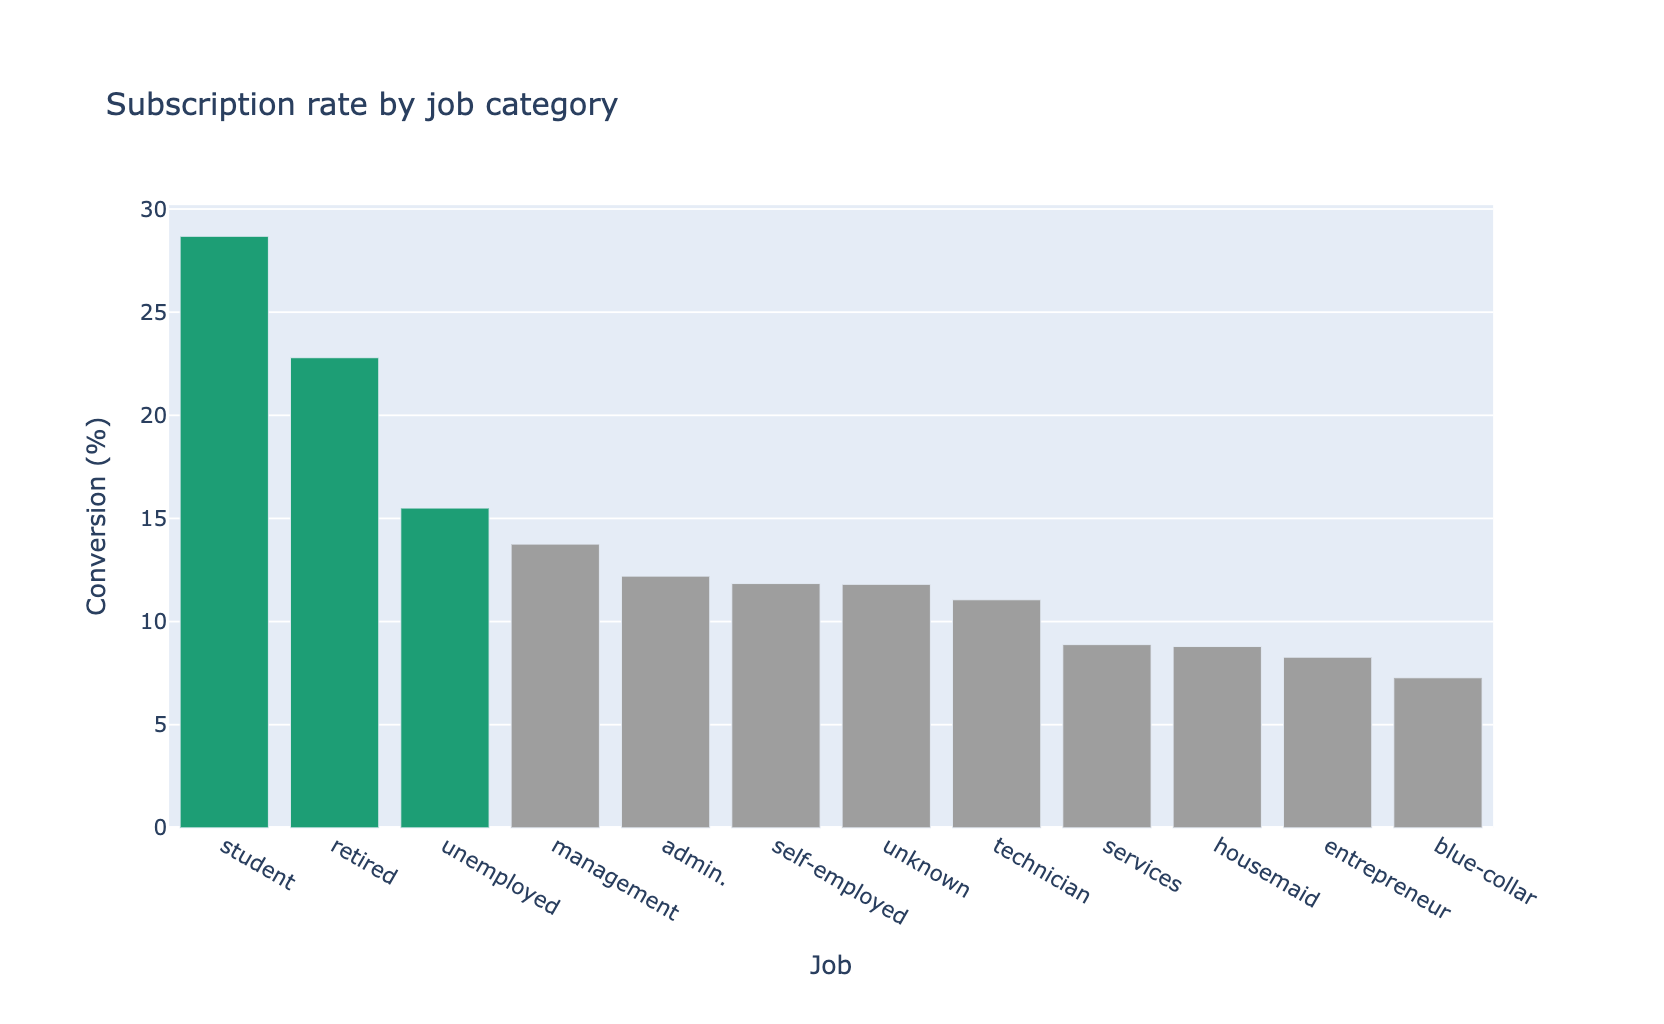

In [ ]:
import plotly.graph_objects as go

colors = [
    "#1d9e75" if pct > 15 else "#9e9e9e"
    for pct in by_job["conversion_pct"].to_list()
]
fig = go.Figure(
    data=[
        go.Bar(
            x=by_job["job"].to_list(),
            y=by_job["conversion_pct"].to_list(),
            marker_color=colors,
        )
    ]
)
fig.update_layout(
    title="Subscription rate by job category",
    xaxis_title="Job",
    yaxis_title="Conversion (%)",
)
fig

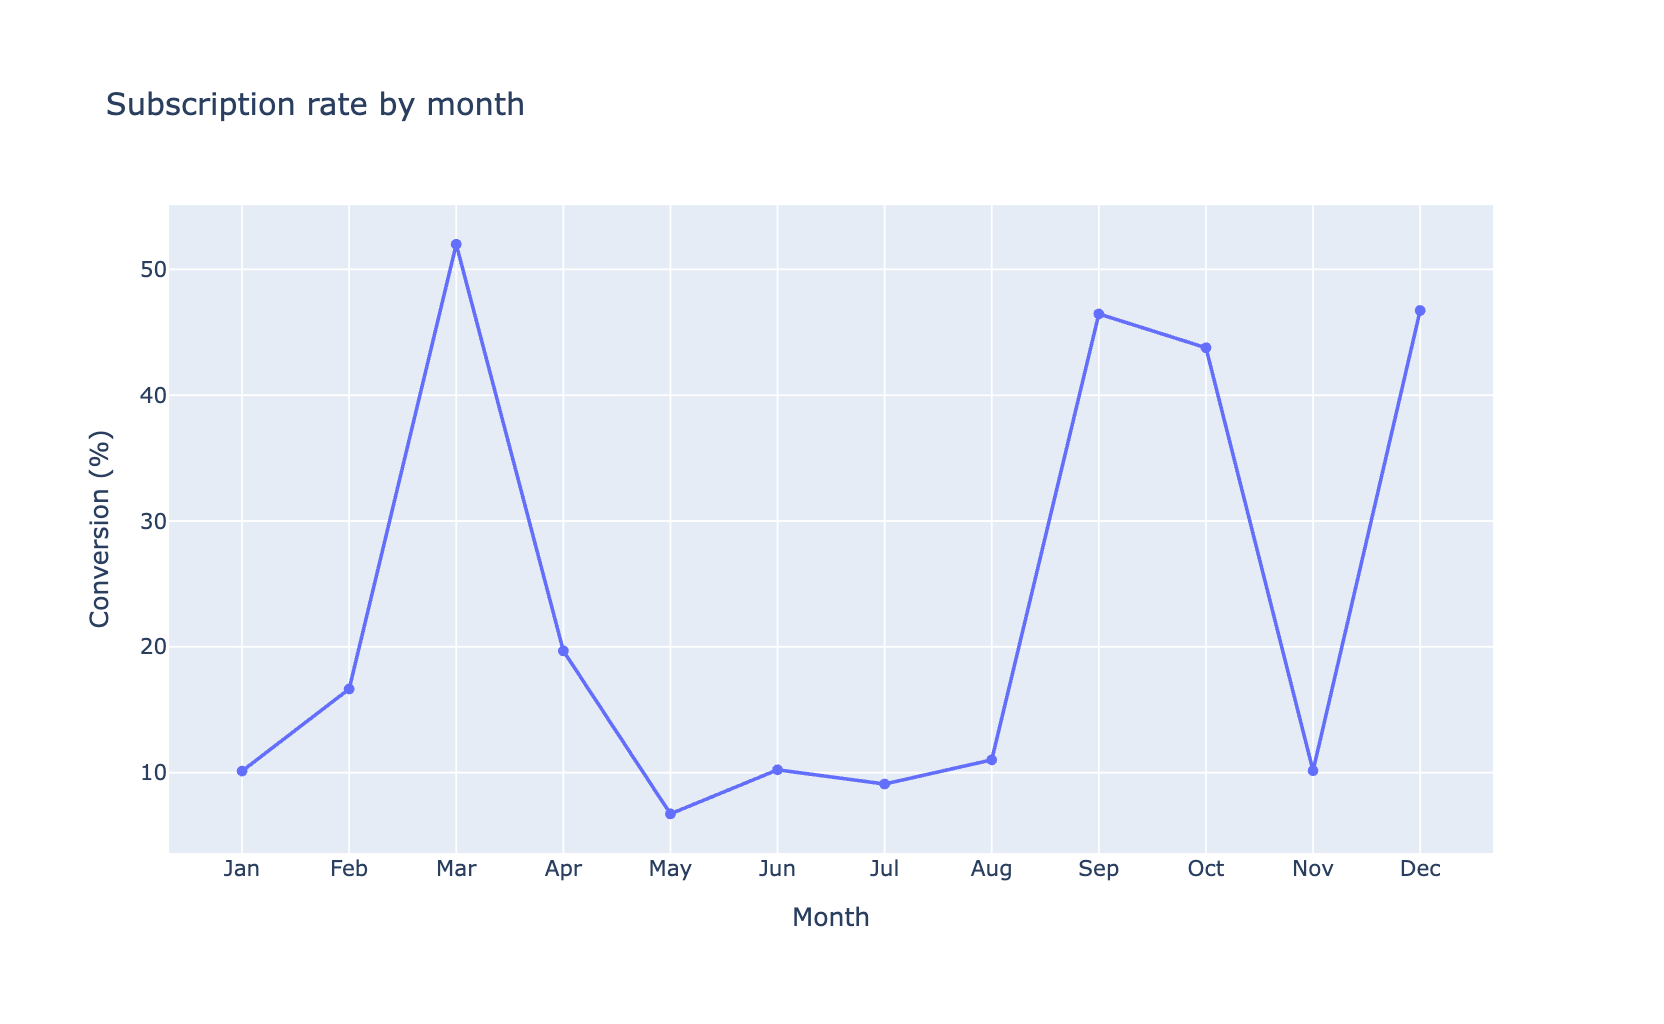

In [ ]:
month_order = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

by_month = (
    df.with_columns(pl.col("month").str.to_lowercase().alias("_month_key"))
    .group_by("_month_key")
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct")
    )
)
ord_df = pl.DataFrame({"_month_key": month_order, "ord": list(range(12))})
by_month = (
    by_month.join(ord_df, on="_month_key", how="left")
    .filter(pl.col("ord").is_not_null())
    .sort("ord")
    .select(
        pl.col("_month_key").str.to_titlecase().alias("month"),
        "contacts",
        "subscribed_yes",
        "conversion_pct",
    )
)

month_fig = go.Figure(
    data=go.Scatter(
        x=by_month["month"].to_list(),
        y=by_month["conversion_pct"].to_list(),
        mode="lines+markers",
    )
)
month_fig.update_layout(
    title="Subscription rate by month",
    xaxis_title="Month",
    yaxis_title="Conversion (%)",
)
month_fig

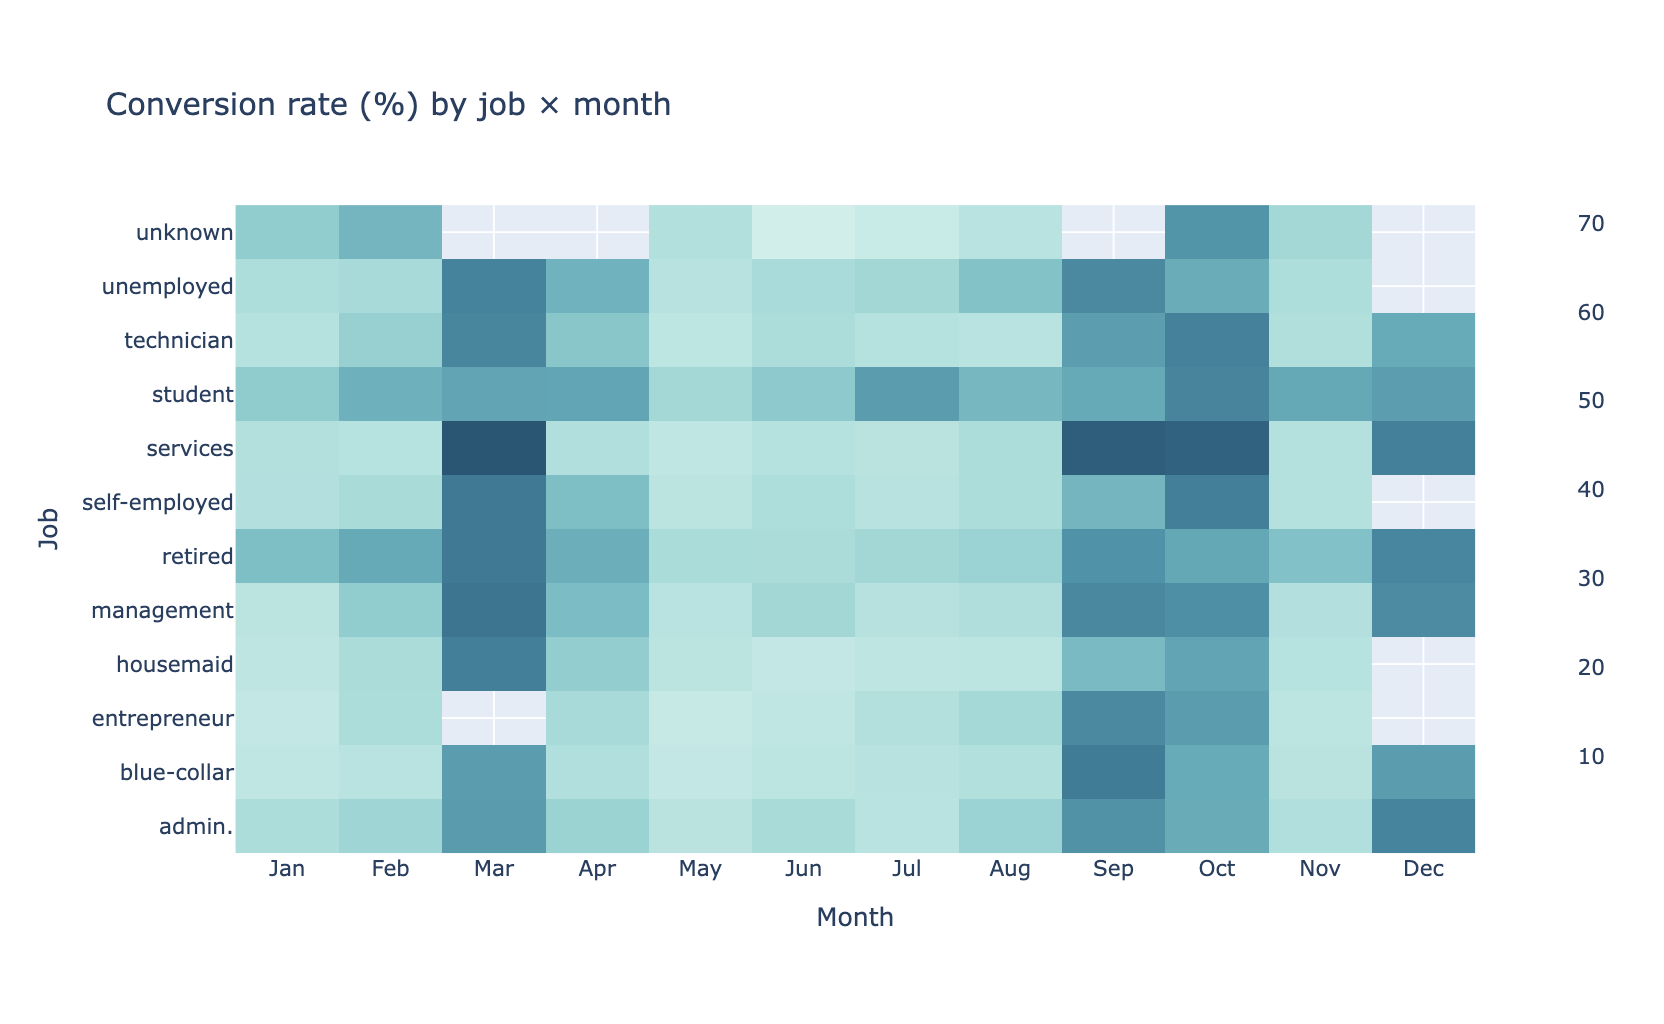

In [ ]:
jm_month_sequence = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
jm_ord_lookup = pl.DataFrame(
    {"_m": jm_month_sequence, "jm_ord": list(range(12))}
)

job_month = (
    df.with_columns(pl.col("month").str.to_lowercase().alias("_m"))
    .group_by(["job", "_m"])
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct")
    )
    .filter(pl.col("contacts") >= 10)
    .join(jm_ord_lookup, on="_m", how="left")
    .filter(pl.col("jm_ord").is_not_null())
)

job_month_wide = job_month.pivot(
    index="job",
    on="_m",
    values="conversion_pct",
    aggregate_function="first",
).sort("job")

jm_month_cols = [m for m in jm_month_sequence if m in job_month_wide.columns]
jm_x_labels = [m[:1].upper() + m[1:] for m in jm_month_cols]
jm_jobs = job_month_wide["job"].to_list()
jm_z = [list(r) for r in job_month_wide.select(jm_month_cols).iter_rows()]

job_month_heatmap_fig = go.Figure(
    data=go.Heatmap(
        z=jm_z,
        x=jm_x_labels,
        y=jm_jobs,
        colorscale="Teal",
    )
)
job_month_heatmap_fig.update_layout(
    title="Conversion rate (%) by job × month",
    xaxis_title="Month",
    yaxis_title="Job",
)
job_month_heatmap_fig

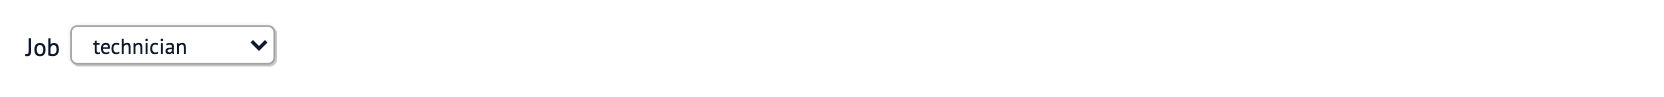

In [ ]:
_job_profile_options = sorted(df["job"].unique().to_list())
job_profile_dropdown = mo.ui.dropdown(
    options=_job_profile_options,
    value="retired",
    label="Job",
)
job_profile_dropdown

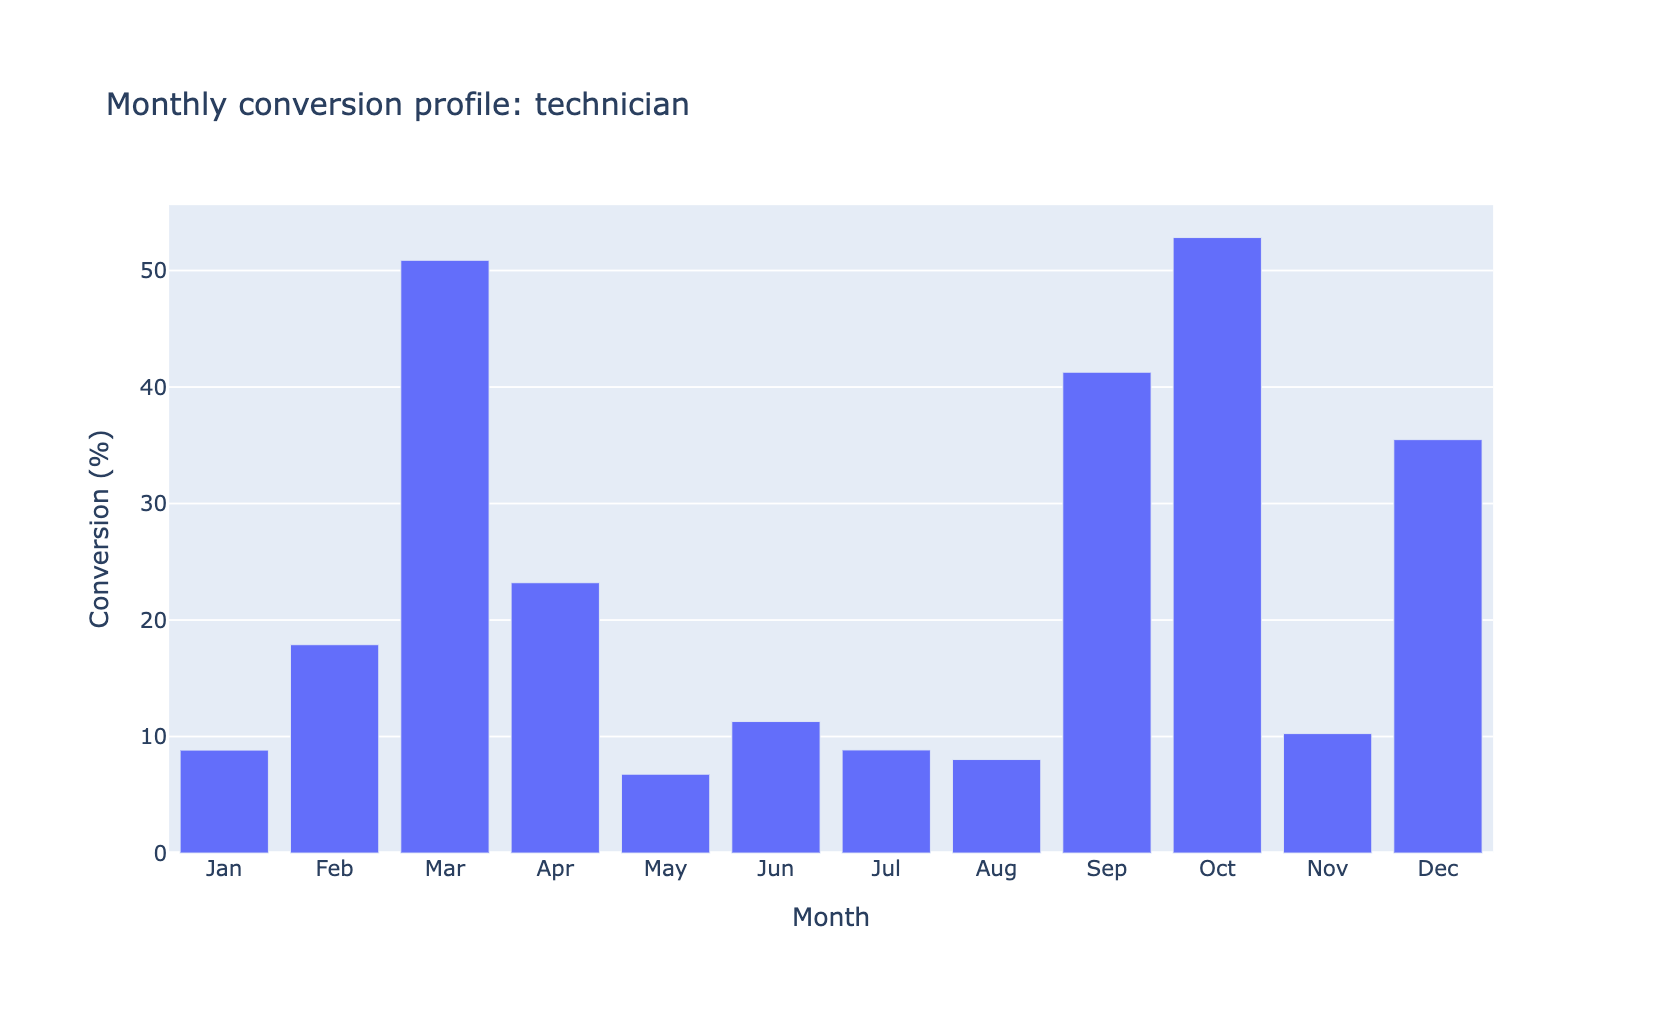

In [ ]:
sel_job = job_profile_dropdown.value
_profile_months = [
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]
_profile_ord = pl.DataFrame(
    {"_m": _profile_months, "_profile_ord": list(range(12))}
)
_sub = df.filter(pl.col("job") == sel_job)
_by_m = (
    _sub.with_columns(pl.col("month").str.to_lowercase().alias("_m"))
    .group_by("_m")
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct")
    )
    .join(_profile_ord, on="_m", how="left")
    .filter(pl.col("_profile_ord").is_not_null())
    .sort("_profile_ord")
)
_prof_x = [m[:1].upper() + m[1:] for m in _by_m["_m"].to_list()]
_prof_y = _by_m["conversion_pct"].to_list()
job_profile_bar_fig = go.Figure(data=go.Bar(x=_prof_x, y=_prof_y))
job_profile_bar_fig.update_layout(
    title=f"Monthly conversion profile: {sel_job}",
    xaxis_title="Month",
    yaxis_title="Conversion (%)",
)
job_profile_bar_fig

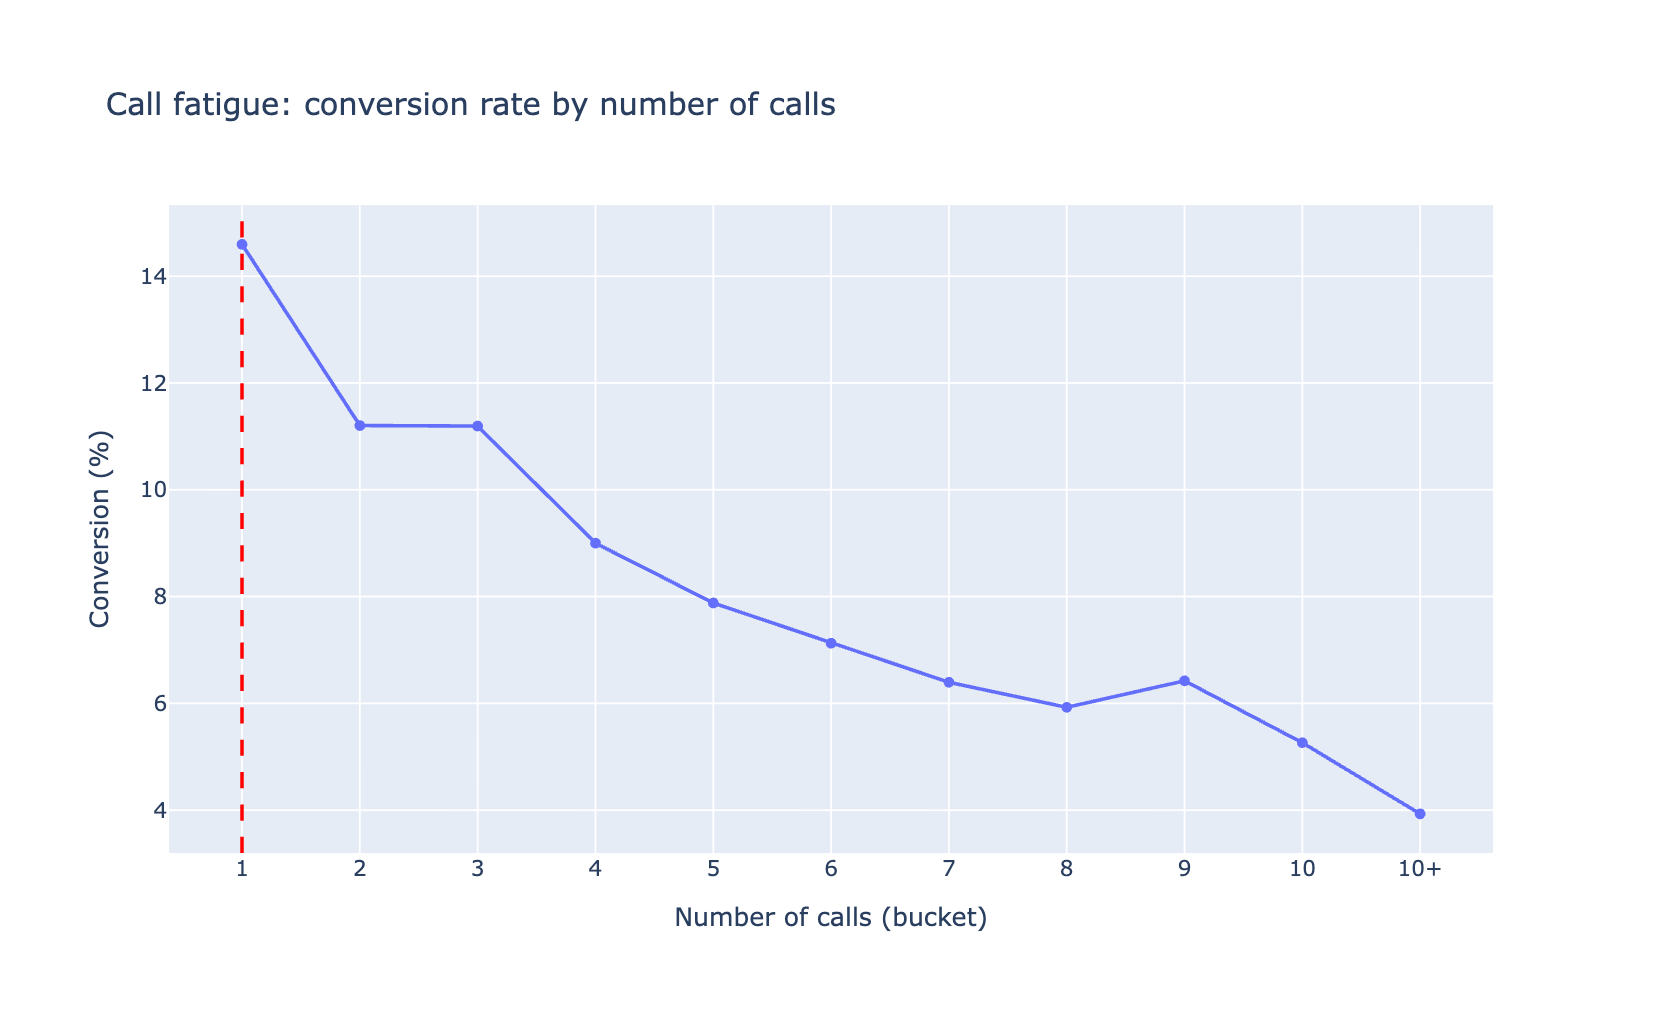

In [ ]:
_cf_prep = df.with_columns(
    pl.when(pl.col("campaign") > 10)
    .then(pl.lit(11))
    .otherwise(pl.col("campaign"))
    .alias("calls_x")
)
_cf_agg = (
    _cf_prep.group_by("calls_x")
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct"),
        pl.when(pl.col("calls_x") == 11)
        .then(pl.lit("10+"))
        .otherwise(pl.col("calls_x").cast(pl.Utf8))
        .alias("call_bucket"),
    )
    .sort("calls_x")
)

_cf_num = _cf_agg
_cf_conv = _cf_num["conversion_pct"].to_list()
_cf_x = _cf_num["calls_x"].to_list()
_cf_lbl = _cf_num["call_bucket"].to_list()
_cf_peak_i = max(range(len(_cf_conv)), key=lambda i: _cf_conv[i])
call_fatigue_peak_x = _cf_x[_cf_peak_i]
call_fatigue_peak_bucket = _cf_lbl[_cf_peak_i]
call_fatigue_peak_pct = _cf_conv[_cf_peak_i]
call_fatigue_cap_i = None
for _j in range(_cf_peak_i + 1, len(_cf_conv)):
    if _cf_conv[_j] < call_fatigue_peak_pct - 8:
        call_fatigue_cap_i = _j
        break
if call_fatigue_cap_i is None:
    call_fatigue_cap_i = min(_cf_peak_i + 1, len(_cf_conv) - 1)
call_fatigue_recommend_bucket = _cf_lbl[call_fatigue_cap_i]

call_fatigue_fig = go.Figure(
    data=go.Scatter(
        x=_cf_num["calls_x"].to_list(),
        y=_cf_num["conversion_pct"].to_list(),
        mode="lines+markers",
        text=_cf_lbl,
        hovertemplate="Calls %{text}: %{y:.2f}%<extra></extra>",
    )
)
call_fatigue_fig.add_vline(
    x=call_fatigue_peak_x,
    line_width=2,
    line_dash="dash",
    line_color="red",
)
call_fatigue_fig.update_layout(
    title="Call fatigue: conversion rate by number of calls",
    xaxis_title="Number of calls (bucket)",
    yaxis_title="Conversion (%)",
    xaxis=dict(
        tickmode="array",
        tickvals=list(range(1, 12)),
        ticktext=[str(i) for i in range(1, 11)] + ["10+"],
    ),
)
call_fatigue_fig

In [ ]:
mo.md(f"""
## Call-cap guidance (ops)

Conversion peaks around **{call_fatigue_peak_bucket}** contact(s) per customer (see the red dashed line). After that, response rates **fall off**—by **{call_fatigue_recommend_bucket}** contacts the curve has usually **dropped enough** that extra dialing mostly adds **cost and annoyance**, not incremental yeses.

**Recommendation for campaign ops:** treat **{call_fatigue_recommend_bucket}** as a practical **call cap** for planning and QA (list rules, cadence, and vendor SLAs), and **reallocate** volume above that toward **new leads** or **better-timed** follow-up rather than stacking more touches on the same names.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="call-cap-guidance-ops">Call-cap guidance (ops)</h2>
<span class="paragraph">Conversion peaks around <strong>1</strong> contact(s) per customer (see the red dashed line). After that, response rates <strong>fall off</strong>—by <strong>7</strong> contacts the curve has usually <strong>dropped enough</strong> that extra dialing mostly adds <strong>cost and annoyance</strong>, not incremental yeses.</span>
<span class="paragraph"><strong>Recommendation for campaign ops:</strong> treat <strong>7</strong> as a practical <strong>call cap</strong> for planning and QA (list rules, cadence, and vendor SLAs), and <strong>reallocate</strong> volume above that toward <strong>new leads</strong> or <strong>better-timed</strong> follow-up rather than stacking more touches on the same names.</span></span>

Accuracy with all numeric features (incl. duration): 0.8881
Accuracy with duration removed: 0.8828


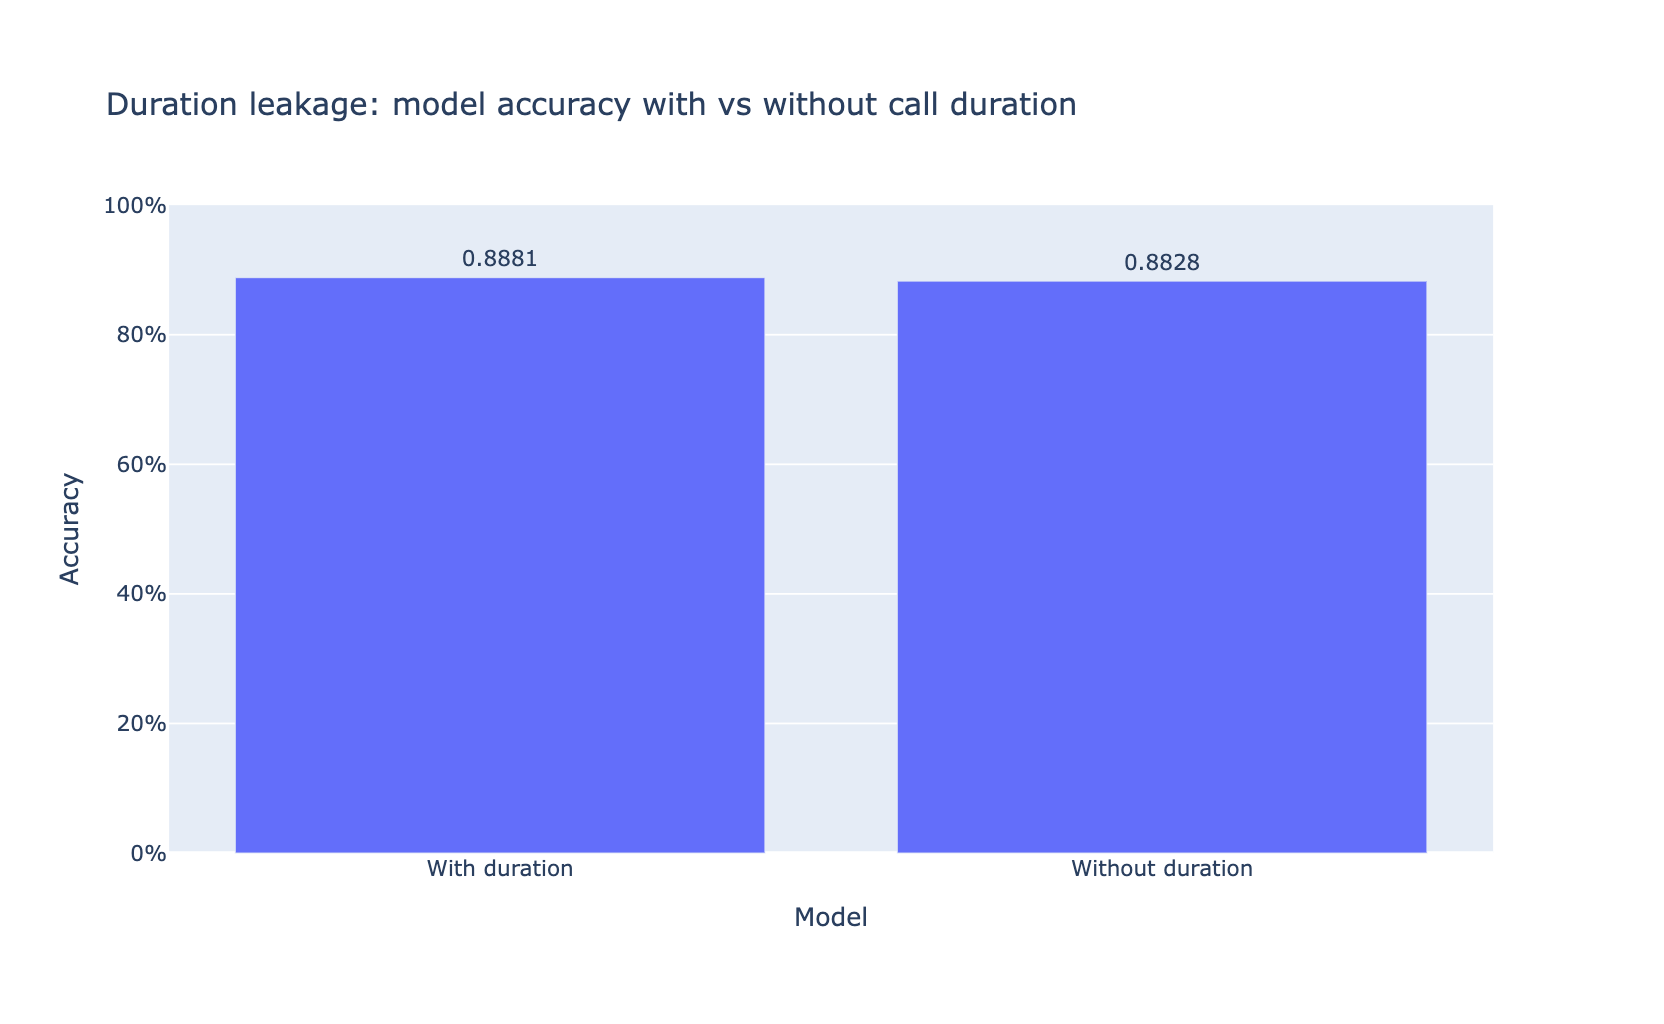

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

_leak_tbl = df.with_columns(
    (pl.col("subscribed") == "yes").cast(pl.Int8).alias("y")
)
_leak_num_feats = [
    c
    for c in _leak_tbl.columns
    if c not in ("subscribed", "y") and _leak_tbl[c].dtype.is_numeric()
]
_X = _leak_tbl.select(_leak_num_feats).to_numpy()
_y = _leak_tbl["y"].to_numpy().ravel()

_X_tr, _X_te, _y_tr, _y_te = train_test_split(
    _X, _y, test_size=0.3, random_state=42, stratify=_y
)

_logit_with_duration = LogisticRegression(max_iter=10_000, solver="lbfgs")
_logit_with_duration.fit(_X_tr, _y_tr)
duration_leak_acc_with = float(accuracy_score(_y_te, _logit_with_duration.predict(_X_te)))
print(
    f"Accuracy with all numeric features (incl. duration): {duration_leak_acc_with:.4f}"
)

_dur_idx = _leak_num_feats.index("duration")
_feat_mask = [j for j in range(len(_leak_num_feats)) if j != _dur_idx]
_X_tr_nd = _X_tr[:, _feat_mask]
_X_te_nd = _X_te[:, _feat_mask]

_logit_no_duration = LogisticRegression(max_iter=10_000, solver="lbfgs")
_logit_no_duration.fit(_X_tr_nd, _y_tr)
duration_leak_acc_without = float(
    accuracy_score(_y_te, _logit_no_duration.predict(_X_te_nd))
)
print(f"Accuracy with duration removed: {duration_leak_acc_without:.4f}")

duration_leakage_acc_fig = go.Figure(
    data=go.Bar(
        x=["With duration", "Without duration"],
        y=[duration_leak_acc_with, duration_leak_acc_without],
        text=[
            f"{duration_leak_acc_with:.4f}",
            f"{duration_leak_acc_without:.4f}",
        ],
        textposition="outside",
    )
)
duration_leakage_acc_fig.update_layout(
    title="Duration leakage: model accuracy with vs without call duration",
    xaxis_title="Model",
    yaxis_title="Accuracy",
    yaxis=dict(range=[0, 1], tickformat=".0%"),
)
duration_leakage_acc_fig

In [ ]:
mo.md(
    f"""## Why `duration` is a leakage variable

**You cannot know call length before you place the call.** `duration` is only realized **during** the conversation, so it is not part of the legitimate **pre-call** information set for targeting or prioritization. Feeding it to a classifier lets the model exploit **post-call** mechanics that would not be available at decision time—classic **temporal / label leakage**.

**What the accuracy gap reveals:** with duration, holdout accuracy reaches **{duration_leak_acc_with:.1%}**; after removing it, accuracy falls to **{duration_leak_acc_without:.1%}** (about **{(duration_leak_acc_with - duration_leak_acc_without) * 100:.1f} points** on the 0–1 scale). That gap is a warning that **naive “use every numeric column” modeling** on this dataset can look strong while mostly **memorizing the call’s aftermath**, not learning a **deployable** pre-call policy. For campaign ops, train and evaluate on **features you would actually have before dialing**."""
)

<span class="markdown prose dark:prose-invert contents"><h2 id="why-duration-is-a-leakage-variable">Why <code>duration</code> is a leakage variable</h2>
<span class="paragraph"><strong>You cannot know call length before you place the call.</strong> <code>duration</code> is only realized <strong>during</strong> the conversation, so it is not part of the legitimate <strong>pre-call</strong> information set for targeting or prioritization. Feeding it to a classifier lets the model exploit <strong>post-call</strong> mechanics that would not be available at decision time—classic <strong>temporal / label leakage</strong>.</span>
<span class="paragraph"><strong>What the accuracy gap reveals:</strong> with duration, holdout accuracy reaches <strong>88.8%</strong>; after removing it, accuracy falls to <strong>88.3%</strong> (about <strong>0.5 points</strong> on the 0–1 scale). That gap is a warning that <strong>naive “use every numeric column” modeling</strong> on this dataset can look strong while mostly <strong>memorizing the call’s aftermath</strong>, not learning a <strong>deployable</strong> pre-call policy. For campaign ops, train and evaluate on <strong>features you would actually have before dialing</strong>.</span></span>

In [ ]:
mo.md(f"""
## Executive summary

- **Cap outreach at the fatigue cliff:** operationalize a **hard call ceiling around {call_fatigue_recommend_bucket}** contacts per prospect (the post-peak drop-off from the call-fatigue curve) so dialing stops before marginal conversion collapses and budget shifts to fresher leads instead of stacked retries.

- **Target high-lift windows for priority cohorts:** concentrate conversion-oriented campaigns on **retired** and **student** audiences in **March, September, and October**—where we observed the strongest subscription rates—while keeping **May** (for those segments) light until creative, timing, or qualification fixes close the gap.

- **Keep pre-call models honest:** for any **pre-call scoring or prioritization**, **exclude `duration`** (and similarly post-realized call attributes) from feature pipelines so reported accuracy reflects **decision-time** information only—avoiding leakage-driven optimism that would misroute lists and vendor incentives.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="executive-summary">Executive summary</h2>
<ul>
<li><strong>Cap outreach at the fatigue cliff:</strong> operationalize a <strong>hard call ceiling around 7</strong> contacts per prospect (the post-peak drop-off from the call-fatigue curve) so dialing stops before marginal conversion collapses and budget shifts to fresher leads instead of stacked retries.</li>
<li><strong>Target high-lift windows for priority cohorts:</strong> concentrate conversion-oriented campaigns on <strong>retired</strong> and <strong>student</strong> audiences in <strong>March, September, and October</strong>—where we observed the strongest subscription rates—while keeping <strong>May</strong> (for those segments) light until creative, timing, or qualification fixes close the gap.</li>
<li><strong>Keep pre-call models honest:</strong> for any <strong>pre-call scoring or prioritization</strong>, <strong>exclude <code>duration</code></strong> (and similarly post-realized call attributes) from feature pipelines so reported accuracy reflects <strong>decision-time</strong> information only—avoiding leakage-driven optimism that would misroute lists and vendor incentives.</li>
</ul></span>

In [ ]:
mo.md("""
## Campaign prioritization

**Key finding:** For **retired** and **student** customers, outreach in **March**, **September**, or **October** includes job×month combinations where conversion climbs **above 50%**—clear pockets of high intent worth scaling.

The same segments contacted in **May** show conversion in the **single digits** for comparable combinations—much weaker immediate return.

**Recommendation:** Prioritize campaigns, lists, and spend toward **Mar / Sep / Oct** for **retired** and **student** audiences; keep **May** activity for these cohorts **light or experimental** (creative tests, nurture, or qualification) until lift improves.
""")

<span class="markdown prose dark:prose-invert contents"><h2 id="campaign-prioritization">Campaign prioritization</h2>
<span class="paragraph"><strong>Key finding:</strong> For <strong>retired</strong> and <strong>student</strong> customers, outreach in <strong>March</strong>, <strong>September</strong>, or <strong>October</strong> includes job×month combinations where conversion climbs <strong>above 50%</strong>—clear pockets of high intent worth scaling.</span>
<span class="paragraph">The same segments contacted in <strong>May</strong> show conversion in the <strong>single digits</strong> for comparable combinations—much weaker immediate return.</span>
<span class="paragraph"><strong>Recommendation:</strong> Prioritize campaigns, lists, and spend toward <strong>Mar / Sep / Oct</strong> for <strong>retired</strong> and <strong>student</strong> audiences; keep <strong>May</strong> activity for these cohorts <strong>light or experimental</strong> (creative tests, nurture, or qualification) until lift improves.</span></span>

In [ ]:
_pd_jm = (
    df.with_columns(pl.col("month").str.to_lowercase().alias("_m"))
    .group_by(["job", "_m"])
    .agg(
        pl.len().alias("contacts"),
        (pl.col("subscribed") == "yes").sum().alias("subscribed_yes"),
    )
    .with_columns(
        (100.0 * pl.col("subscribed_yes") / pl.col("contacts")).alias("conversion_pct")
    )
    .filter(pl.col("contacts") >= 10)
)
_pd_high = _pd_jm.filter(
    pl.col("job").is_in(["retired", "student"])
    & pl.col("_m").is_in(["mar", "sep", "oct"])
)
_pd_low = _pd_jm.filter(
    pl.col("job").is_in(["retired", "student"])
    & (pl.col("_m") == "may")
)
_pd_best_pct = float(_pd_high["conversion_pct"].max()) if _pd_high.height else float("nan")
_pd_worst_pct = float(_pd_low["conversion_pct"].min()) if _pd_low.height else float("nan")
_pd_gap_pp = _pd_best_pct - _pd_worst_pct

_pd_peak_cut = 10 if call_fatigue_peak_x == 11 else int(call_fatigue_peak_x)

mo.md(
    f"""## What this means 
for campaign pipeline design

On the job×month heatmap (≥10 contacts per cell), **retired**/**student** combinations peak at **{_pd_best_pct:.1f}%** conversion in **March / September / October**, versus **{_pd_worst_pct:.1f}%** at the weakest **May** cells for those same jobs—a **{_pd_gap_pp:.1f} percentage-point** spread that dwarfs typical creative tests.

- ROUTE: Cap outreach to retired and student segments exclusively to March, September, and October. All other months: suppress or hold for nurture only.

- GATE: Add a campaign count filter — drop any contact record where campaign > {_pd_peak_cut}. Do not call past that threshold.

- SCORE: Exclude "duration" from any pre-call propensity model. It is a post-call variable and including it is data leakage — models trained with it are unusable in production.

These three rules can be implemented as pipeline filters upstream of any dashboard or model — no retraining required."""
)

<span class="markdown prose dark:prose-invert contents"><h2 id="what-this-means">What this means</h2>
<span class="paragraph">for campaign pipeline design</span>
<span class="paragraph">On the job×month heatmap (≥10 contacts per cell), <strong>retired</strong>/<strong>student</strong> combinations peak at <strong>56.1%</strong> conversion in <strong>March / September / October</strong>, versus <strong>12.1%</strong> at the weakest <strong>May</strong> cells for those same jobs—a <strong>43.9 percentage-point</strong> spread that dwarfs typical creative tests.</span>
<ul>
<li>ROUTE: Cap outreach to retired and student segments exclusively to March, September, and October. All other months: suppress or hold for nurture only.</li>
<li>GATE: Add a campaign count filter — drop any contact record where campaign &gt; 1. Do not call past that threshold.</li>
<li>SCORE: Exclude "duration" from any pre-call propensity model. It is a post-call variable and including it is data leakage — models trained with it are unusable in production.</li>
</ul>
<span class="paragraph">These three rules can be implemented as pipeline filters upstream of any dashboard or model — no retraining required.</span></span>